In [11]:
import json
import networkx as nx
import matplotlib.pyplot as plt

In [12]:
dgidb_genes_dict = {}

In [13]:
disease_list = ["BIPOLAR","BREASTCANCER","LEUKEMIA","SCHIZOPHRENIA"]

In [14]:
for d in disease_list:
    with open(f"../../Gen_Hypergraph/output/DGIDB_{d}/" + f"gene_to_index.json", "r") as file:
        DGIDB_gene_to_index = json.load(file)
    DGIDB_genes = set(DGIDB_gene_to_index.keys())
    dgidb_genes_dict[d] = DGIDB_genes

In [15]:
def num_common_genes(d1,d2):
    return len(dgidb_genes_dict[d1] & dgidb_genes_dict[d2])

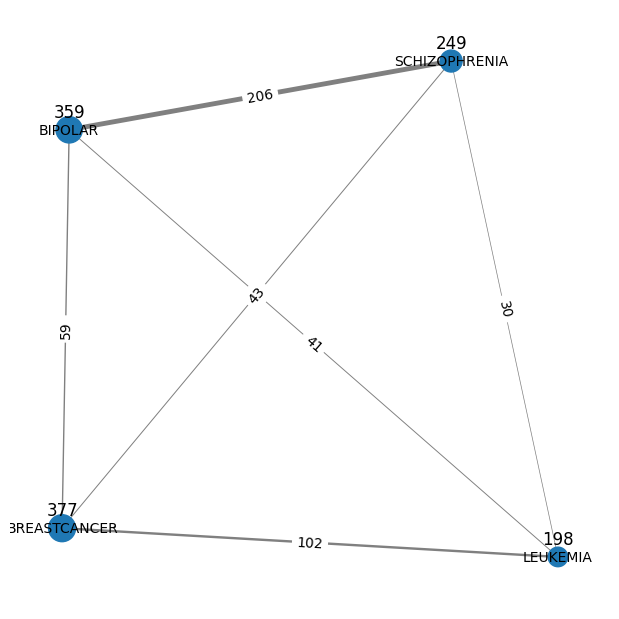

In [16]:
G = nx.Graph()

# add nodes with size attribute
for d in disease_list:
    G.add_node(d, size=len(dgidb_genes_dict[d]))

# add weighted edges for all pairs
for i in range(len(disease_list)):
    for j in range(i + 1, len(disease_list)):
        w = num_common_genes(disease_list[i], disease_list[j])
        G.add_edge(disease_list[i], disease_list[j], weight=w)

# -----------------------------
# Draw the graph
# -----------------------------
pos = nx.spring_layout(G, k=0.5, iterations=200, seed=28)

node_sizes = [G.nodes[n]['size'] for n in G.nodes]
edge_weights = [G[u][v]['weight'] for u, v in G.edges]

plt.figure(figsize=(6, 6))

w = edge_weights
w_min, w_max = min(w), max(w)
edge_widths = [(x - w_min) / (w_max - w_min + 1e-9) * 3 + 0.5 for x in w]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=node_sizes,
    width=edge_widths,          # edge width proportional to similarity
    edge_color='gray',
    font_size=10
)

label_pos = {n: (x, y + 0.07) for n, (x, y) in pos.items()}
nx.draw_networkx_labels(G, label_pos, labels={n: G.nodes[n]['size'] for n in G.nodes})
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.savefig(f"../../Graphs/gene_overlap.png", bbox_inches="tight")

plt.show()